# Predicting a song’s popularity

## Introduction

This project will be around leveraging the power of distributed systems and using machine learning techniques on big data to create a model that can make predictions on unseen data. The first step in this project was to find a suitably large data set on Kaggle. The current project will be using the Spotify dataset, which was downloaded from [here](https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks?resource=download). The data set is around 81MB, which would no longer be considered big data today, however it is suitable for the preliminary data wrangling and model building. If the model is promising (i.e. has a strong predictive power), the analysis can be scaled out to a larger data set. 

The data wrangling and model building will be conducted using both PySpark and MLlib. PySpark is a Python API which allows access to Apache Spark using the python programming language, which allows for large scale data processing, in a distributed manner [1]. This allows a user familiar with the python programming language to leverage the distributed strengths of Apache Spark. MLlib is a library that is built on top of Spark and allows the user to build machine learning pipelines that can be executed in a distributed way, thanks to Spark [1].  

The data set contains 1,000,000 songs and each song has 19 features that describes the characteristics of the song. The following table shows the name of each feature, what they measure, and the possible values that can be given. 

|Feature Name|Description|Values|
|:---|:---|:---:|
|**Row ID**|The songs row ID.||
|**Artist Name**|The artistis name of the song. ||
|**Track Name**|The name of the song. ||
|**Track ID**|The ID of the track in Spotify.||
|**Popularity**|The songs popularity.|0 to 100|
|**Year**|The year the song was released|2000 to 2023|
|**Genre**|The genre of the song. ||
|**Danceability**|How danceable is the song?|0 to 1|
|**Energy**|The perceived intensity and activity of the song. |0 to 1|
|**Key**|The key the song is in. |0 to 11|
|**Loudness**|Overall loudness of the song in decibels. |-60 to 7|
|**Mode**|Modality of the song. |0 or 1|
|**Speechiness**|Presence of spoken words in the song. |0 to 1|
|**Acousticness**|Confidence measure of whether the song is acoustic. |0 to 1|
|**Instrumentalness**|Does the song contain vocals?|0 to 1|
|**Liveness**|Is there an audience in the recording?|0 to 1|
|**Valence**|Is the song positive?|0 to 1|
|**Tempo**|Tempo of the song in beats per minute (BPM)|0 to 250|
|**Duration ms**|Duration of the song in milliseconds (ms)|2073 to 6000495|
|**Time Signature**|Estimated time signature of the song. |0 to 5|

The nature of the project will be exploratory, looking into whether it would be possible to see whether it is possible to predict whether a song will be popular or not based on the song’s characteristics. This would be useful for those who want to predict the popularity of a song based on a song´s characteristics. For instance, a record label who would like to get an idea of the sellability of a potential artist. Or Spotify, who might want to check a song’s popularity, so that they can push certain songs to listeners. 

**Hypothesis**: *Using the song’s characteristics, can the song’s popularity be predicted?* 

Four different approaches will be used to see whether there is a relationship between the song’s features and whether it will be considered popular: Linear Regression (LR), Logistic Regression (LGR), Random Forest Classifier (RFC), and Random Forest Regressor (RFR). 

Linear regression will create a model that computes a weighted sum of the inputted features to make a prediction of a song’s popularity (i.e. 0 to 100) [2]. This is an interesting approach, since the scale of the outcome remains the same as the original. The same will occur with the RFR, with an outcome that will range from 0 to 100. The other two techniques, LGR and RFC, both need the dependent variable (i.e. popularity), to be a dichotomous variable [2]. Therefore, the popularity feature will be turned into a dichotomous feature, with scores less than 59 indicating unpopular (0) and score of 60 and higher indicating popular (1). The reasoning behind this is the assumption that if 6 people out of 10 like a song, it can be interpreted as popular. This deviates from the original feature, but would indicate whether a song has a higher chance of being a popular song. 

## Methods

Once the data set was downloaded from Kaggle, the data set was moved onto Lena. Once there, the data set was transferred to Hadoop, which would allow the usage of the distributed file system to run the analysis. The next step was to ensure that all the necessary libraries were imported to conduct the relevant analysis and the SparkContext was initialized. 

The data set was first looked at using pandas, which allowed for a quick way of getting a feel for the data. Both descriptive statistics and histograms were generated for all the numeric features. 

The descriptive data corroborates the table above, illustrating that there were differing scales between the features, which would mean that the data would need to be scaled before a model could be built. This would mainly be a concern with both the Linear and Logistic regression. In the case of the RFR and RFC, it would not be a problem to use the original scales of the features. 

In [6]:
# Getting the descriptions of the numerica features. 
data.describe()

,Unnamed: 0,popularity,year,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06,1.159764e+06
mean,6.590613e+05,1.838312e+01,2.011955e+03,5.374382e-01,6.396699e-01,5.287778e+00,-8.981353e+00,6.346533e-01,9.281477e-02,3.215370e-01,2.523489e-01,2.230189e-01,4.555636e-01,1.213771e+02,2.495618e+05,3.885879e+00
std,4.285492e+05,1.588554e+01,6.803901e+00,1.844780e-01,2.705009e-01,3.555197e+00,5.682215e+00,4.815275e-01,1.268409e-01,3.549872e-01,3.650731e-01,2.010707e-01,2.685190e-01,2.977975e+01,1.494262e+05,4.676967e-01
min,0.000000e+00,0.000000e+00,2.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,-5.810000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.073000e+03,0.000000e+00
25%,2.899408e+05,5.000000e+00,2.006000e+03,4.130000e-01,4.540000e-01,2.000000e+00,-1.082900e+01,0.000000e+00,3.710000e-02,6.400000e-03,1.050000e-06,9.790000e-02,2.260000e-01,9.879700e+01,1.810910e+05,4.000000e+00
50%,5.798815e+05,1.500000e+01,2.012000e+03,5.500000e-01,6.940000e-01,5.000000e+00,-7.450000e+00,1.000000e+00,5.070000e-02,1.470000e-01,1.760000e-03,1.340000e-01,4.380000e-01,1.219310e+02,2.257440e+05,4.000000e+00
75%,1.031689e+06,2.900000e+01,2.018000e+03,6.770000e-01,8.730000e-01,8.000000e+00,-5.276000e+00,1.000000e+00,8.900000e-02,6.400000e-01,6.140000e-01,2.920000e-01,6.740000e-01,1.399030e+02,2.869135e+05,4.000000e+00
max,1.473395e+06,1.000000e+02,2.023000e+03,9.930000e-01,1.000000e+00,1.100000e+01,6.172000e+00,1.000000e+00,9.710000e-01,9.960000e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.499930e+02,6.000495e+06,5.000000e+00


Looking at the graphs, the numerical features in the data set were clearly not normally distributed, except for Danceability. This would likely cause problems when trying to build a predictive model. The dependent variable, popularity, was very positively skewed, which would mean that it was necessary to try and balance out the data set so that the lower values of popularity were not so prevalent in the data set. 

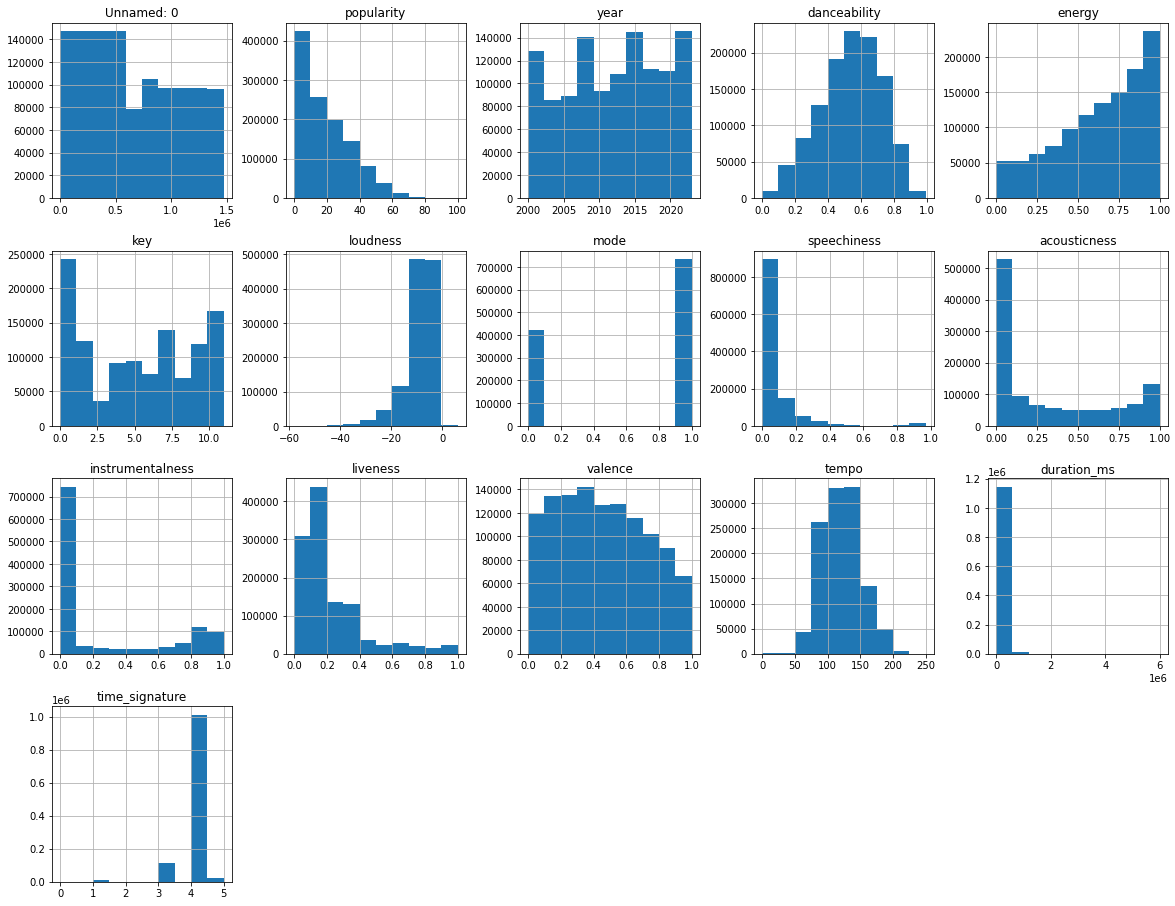

In [8]:
# Graphing the distribution of all the numerical features. 
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html

hist = data.hist(figsize = (20,20), layout = (5,5))

<AxesSubplot:>

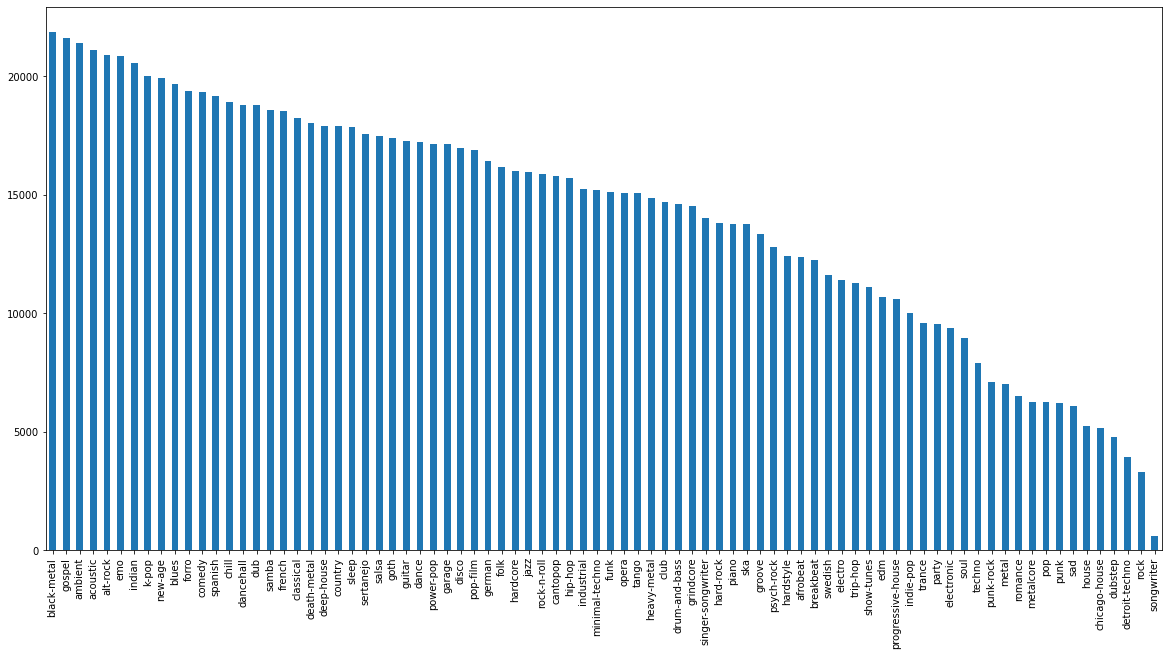

In [9]:
# Distribution of the genres. 
data.genre.value_counts().plot(kind='bar', figsize = (20,10))

To leverage the distributed system of Spark, a DataFrame was created. When the DataFrame was initially created, there were a lot of rows that suddenly had missing data and the schema could not be inferred. This was because some song titles had double quotations in them, which was interpreted as a delimiter by the function. Once solved, by using the escape parameter, the DataFrame was created. A short investigation was conducted to ensure that the values were in line with what was seen during the pandas analysis. 

In [12]:
# Getting the data types of the features. 
df3.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_id: string (nullable = true)
 |-- popularity: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- genre: string (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- time_signature: integer (nullable = true)



In [13]:
# Summarizing the numerical features. 
df3_numeric = df3.select('popularity','year','danceability','energy','key')
df3_numeric.describe().show()

+-------+------------------+-----------------+-------------------+-------------------+------------------+
|summary|        popularity|             year|       danceability|             energy|               key|
+-------+------------------+-----------------+-------------------+-------------------+------------------+
|  count|           1159764|          1159764|            1159764|            1159764|           1159764|
|   mean| 18.38312277325387|2011.955000327653| 0.5374382319161611| 0.6396698993142899| 5.287778375600554|
| stddev|15.885544539482469| 6.80390050198547|0.18447803659457523|0.27050088106567105|3.5551969090419484|
|    min|                 0|             2000|                0.0|                0.0|                 0|
|    max|               100|             2023|              0.993|                1.0|                11|
+-------+------------------+-----------------+-------------------+-------------------+------------------+



In [14]:
df3_numeric2 = df3.select('loudness','mode','speechiness','acousticness','instrumentalness')
df3_numeric2.describe().show()

+-------+------------------+-------------------+-------------------+------------------+-------------------+
|summary|          loudness|               mode|        speechiness|      acousticness|   instrumentalness|
+-------+------------------+-------------------+-------------------+------------------+-------------------+
|  count|           1159764|            1159764|            1159764|           1159764|            1159764|
|   mean|-8.981352824367521| 0.6346532570419499|0.09281476791830595|0.3215369575202091|0.25234888867411903|
| stddev| 5.682214962429573|0.48152746577477645|0.12684091523415636|0.3549872137289241| 0.3650730853071388|
|    min|             -58.1|                  0|                0.0|               0.0|                0.0|
|    max|             6.172|                  1|              0.971|             0.996|                1.0|
+-------+------------------+-------------------+-------------------+------------------+-------------------+



In [15]:
df3_numeric3 = df3.select('liveness','valence','tempo','duration_ms','time_signature')
df3_numeric3.describe().show()

+-------+-------------------+-------------------+------------------+------------------+------------------+
|summary|           liveness|            valence|             tempo|       duration_ms|    time_signature|
+-------+-------------------+-------------------+------------------+------------------+------------------+
|  count|            1159764|            1159764|           1159764|           1159764|           1159764|
|   mean|0.22301887352942976| 0.4555635960341849|121.37713723309135|249561.78122359377|  3.88587936856119|
| stddev|0.20107070354637477|0.26851898180703154| 29.77974885010742|149426.16452247242|0.4676966979664214|
|    min|                0.0|                0.0|               0.0|              2073|                 0|
|    max|                1.0|                1.0|           249.993|           6000495|                 5|
+-------+-------------------+-------------------+------------------+------------------+------------------+



## Analysis

#### Correlations

It was important to investigate whether the features strongly correlate with each other, since an assumption for many forms of analysis is that there is no multicollinearity between features. Based on the table below, multicollinearity was not really a concern. The two correlations that might be a concern was between “Loudness” and “Energy” at 0.78 and “Valence” and “Danceability” at 0.52, which would be considered a large and medium correlation respectively. 

A point of concern was that there was no correlations between any feature and popularity. This indicates that there was no clear linear relationship between any feature and popularity. This should be looked at with caution, since a correlation indicates a linear relationship and thus there might be another type of relationship present (i.e. nonlinear relationship). This would be a problem with the linear regression but would be something that the random forest approach would be able to detect. 

||Popularity|Danceability|Energy|Key|Loudness|Mode|Speechiness|Acousticness|Instrugmentalness|Liveness|Valence|Tempo|Duration in ms|Time Signature|
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
|**Popularity**|1||||||||||||||
|**Danceability**|0.1|1|||||||||||||
|**Energy**|0.01|0.14|1||||||||||||
|**Key**|0|0.03|0.04|1|||||||||||
|**Loudness**|0.1|**0.26**|**0.78**|0.03|1||||||||||
|**Mode**|-0.02|-0.05|-0.05|-0.17|-0.02|1|||||||||
|**Speechiness**|-0.02|0.09|0.11|0.01|0.02|-0.02|1||||||||
|**Acousticness**|-0.06|-0.18|-0.75|-0.03|-0.62|0.07|0.03|1|||||||
|**Instrugmentalness**|-0.15|-0.17|-0.18|0|-0.4|-0.06|-0.14|0.09|1||||||
|**Liveness**|-0.06|-0.12|0.19|-0.01|0.09|0.02|**0.28**|-0.03|-0.13|1|||||
|**Valence**|-0.02|**0.52**|**0.25**|0.03|**0.29**|0.02|0.04|-0.1|-0.32|0.01|1||||
|**Tempo**|0|-0.02|**0.27**|0.01|**0.23**|-0.01|-0.03|-0.24|-0.03|0|0.08|1|||
|**Duration in ms**|-0.12|-0.03|0.01|0.01|-0.05|-0.04|-0.06|-0.06|0.16|-0.01|-0.13|0.01|1||
|**Time Signature**|0.03|0.18|0.17|0.01|0.17|-0.02|-0.03|-0.17|-0.06|-0.02|0.12|0.06|0.02|1|

#### Creating the pipelines

From there, the necessary objects were created for the different pipelines that would be executed. The first object created was “vector”, which took all the numerical features and turned them into a vector. This would be sufficient for the RFC and the RFR. 

This then allowed for the following two objects to be created: “ss_1” and “mm_1”. The ss_1 object used the StandardScaler to scale the features, converting them to have a standard deviation of 1. The mm_1 object used the MinMaxScaler to scale the features, which converted the features to have a minimum value of 0 and a maximum value of 1. For features that already had a minimum value of 0 and a maximum value of 1, nothing would change for them (i.e. Energy). This type of scaling would be necessary for both LR and LGR.

The different models must be evaluated, so that a decision could be made on which model would be best to use to predict the popularity of a song. In the case of the regression functions (LR and RFR), the RegressionEvaluator was used. The default metric of this object was the RMSE, which is the Root Mean Square Error (RMSE). However, it was possible to calculate both the R^2 and Mean Absolute Error (MAE). For the classifiers, both the BinaryClassificationEvaluator and MultclassClassificationEvaluator were used. The first provides the AUC-ROC and the second provides the accuracy, precision, and recall statistics. 

There was an object that allowed the creation of a dichotomous feature. The function used was the Bucketizer, which allowed the user to define how the feature should be binned. 

Lastly, there was a method used to create a data set that would be more balanced around the dependent feature (i.e. popularity). There was an overwhelming number of songs that had a very low popularity score and thus, it was decided to try to run the analysis using a data set that has limited the number of songs at a certain popularity level to 15,000 songs. Levels of popularity less than 15,000 in total would remain untouched. The method used was the sampleBy(), which allowed the user to provide the percentage to be used for each level of popularity. 

In [118]:
# Creating the different stages for the pipelines.
# Do not want to include the popularity variable when standardising. 

# Vector. 
vector = VectorAssembler(inputCols= ['danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature'], outputCol="features")

vector_sf = VectorAssembler(inputCols= ['danceability','energy','loudness','instrumentalness','valence','duration_ms'], outputCol="features")

# Different scaling methods. 
ss_1 = StandardScaler(inputCol = "features", outputCol = "sscaled", withStd=True, withMean=False)

mm_1 = MinMaxScaler(inputCol = "features", outputCol = "mmscaled")

# Different regression evaluations. 
reg_evaluator = RegressionEvaluator(predictionCol = 'lg_pred', labelCol='popularity')

reg_evaluator_l1 = RegressionEvaluator(predictionCol = 'lg_pred', labelCol='popularity', metricName = 'mae')

log_evaluator = BinaryClassificationEvaluator(rawPredictionCol="log_pred", labelCol="pop_dich")

log_multi_evaluator = MulticlassClassificationEvaluator(labelCol="pop_dich", predictionCol="log_pred")

# Creating the binary popularity variable. Setting it to 59 and less, not popular and 60 above as popular. 
split = [-float("inf"), 59.0, float("inf")]

bucketizer = Bucketizer(splits=split, inputCol="popularity", outputCol="pop_dich")


In [19]:
# Creating the binar variable for popularity. 

df3_update = bucketizer.transform(df3)

In [20]:
# Checking whether the buketizer worked. 
df3_update.show(3)

+---+-------------+----------------+--------------------+----------+----+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+--------+
|_c0|  artist_name|      track_name|            track_id|popularity|year|   genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|pop_dich|
+---+-------------+----------------+--------------------+----------+----+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+--------+
|  0|   Jason Mraz| I Won't Give Up|53QF56cjZA9RTuuMZ...|        68|2012|acoustic|       0.483| 0.303|  4| -10.058|   1|     0.0429|       0.694|             0.0|   0.115|  0.139|133.406|     240166|             3|     1.0|
|  1|   Jason Mraz|93 Million Miles|1s8tP3jP4GZcyHDsj...|        50|2012|acoustic|       0.572| 0.454|  

In [21]:
# Train and Test Set
testset,trainset = df3_update.randomSplit([0.3,0.7], seed=361950)

In [22]:
# Checking popularity distribution. 
df3_update.groupBy('popularity').count().show(101)

+----------+------+
|popularity| count|
+----------+------+
|        31| 16863|
|        85|    29|
|        65|  1102|
|        53|  4089|
|        78|   127|
|        34| 14735|
|        81|   103|
|        28| 18725|
|        76|   234|
|        27| 19164|
|        26| 19644|
|        44|  8191|
|        12| 27297|
|        91|     5|
|        22| 20240|
|        93|     3|
|        47|  6645|
|         1| 39820|
|        52|  4474|
|        13| 26301|
|        16| 25168|
|         6| 27628|
|        86|    14|
|         3| 28592|
|        40| 10519|
|        20| 22318|
|        94|     1|
|        57|  2988|
|        54|  3784|
|        96|     1|
|        48|  6265|
|         5| 25289|
|        19| 22964|
|        92|     5|
|        64|  1218|
|        41|  9911|
|        43|  8744|
|        15| 25466|
|        37| 12774|
|        61|  1845|
|        88|     5|
|        17| 24267|
|         9| 29249|
|        72|   394|
|        35| 14130|
|         4| 25929|
|        59|  2366|


In [22]:
# Indication the percentage that should be selected for each level of popularity. 
frac_dict = {0 : 0.09, 1 : 0.38, 2 : 0.48, 3 : 0.52, 4 : 0.58, 5 : 0.59, 6 : 0.54, 7 : 0.52, 8 : 0.49, 9 : 0.51, 
             10 : 0.52, 11 : 0.53, 12 : 0.55, 13 : 0.57, 14 : 0.58, 15 : 0.59, 16 : 0.6, 17 : 0.62, 18 : 0.63, 
             19 : 0.65, 20 : 0.67, 21 : 0.69, 22 : 0.74, 23 : 0.78, 24 : 0.74, 25 : 0.75, 26 : 0.76, 27 : 0.78, 
             28 : 0.8, 29 : 0.84, 30 : 0.86, 31 : 0.89, 32 : 0.93, 33 : 0.96, 34 : 1, 35 : 1, 36 : 1, 37 : 1, 38 : 1, 
             39 : 1, 40 : 1, 41 : 1, 42 : 1, 43 : 1, 44 : 1, 45 : 1, 46 : 1, 47 : 1, 48 : 1, 49 : 1, 50 : 1, 51 : 1, 
             52 : 1, 53 : 1, 54 : 1, 55 : 1, 56 : 1, 57 : 1, 58 : 1, 59 : 1, 60 : 1, 61 : 1, 62 : 1, 63 : 1, 64 : 1, 
             65 : 1, 66 : 1, 67 : 1, 68 : 1, 69 : 1, 70 : 1, 71 : 1, 72 : 1, 73 : 1, 74 : 1, 75 : 1, 76 : 1, 77 : 1, 
             78 : 1, 79 : 1, 80 : 1, 81 : 1, 82 : 1, 83 : 1, 84 : 1, 85 : 1, 86 : 1, 87 : 1, 88 : 1, 89 : 1, 90 : 1, 
             91 : 1, 92 : 1, 93 : 1, 94 : 1, 95 : 1, 96 : 1, 100 : 1}

df3_update_balance = df3_update.sampleBy("popularity", fractions=frac_dict, seed=361950)

In [24]:
# Checking whether it worked. 
df3_update_balance.groupBy('popularity').count().show(101)

+----------+-----+
|popularity|count|
+----------+-----+
|        31|14980|
|        85|   29|
|        65| 1102|
|        53| 4089|
|        78|  127|
|        34|14735|
|        81|  103|
|        28|14959|
|        76|  234|
|        26|14846|
|        27|14994|
|        44| 8191|
|        12|14959|
|        91|    5|
|        22|14884|
|        93|    3|
|        47| 6645|
|         1|15070|
|        52| 4474|
|        13|15011|
|         6|14974|
|        16|15160|
|        86|   14|
|         3|14860|
|        40|10519|
|        20|15009|
|        94|    1|
|        57| 2988|
|        54| 3784|
|        96|    1|
|        48| 6265|
|         5|15021|
|        19|14834|
|        92|    5|
|        64| 1218|
|        41| 9911|
|        43| 8744|
|        15|15133|
|        37|12774|
|        61| 1845|
|        88|    5|
|        17|15061|
|         9|14878|
|        72|  394|
|        35|14130|
|        55| 3441|
|         4|15087|
|        59| 2366|
|         8|14796|
|       100|

In [23]:
# Creating the balanced test and train sets. 
testset2,trainset2 = df3_update_balance.randomSplit([0.3,0.7], seed=361950)

#### Linear and Logistic Regressions

The guide used to run the different model came from the following sites [3][4]. The goal was to set up the regression specific pipeline and build a parameter grid that would allow the testing of a regression model with a different combination of parameter values. The parameters that were manipulated were “regParam” and “elasticNetParam”. The former effects how heavily the regularization was applied to the model, thus attempting to reduce overfitting of the training set [5]. The latter effects what regularization was used on the model: Ridge, Lasso, or a combination of the two [5]. A total of 12 models were tested based on the parameters defined in the parameter grid. Once set, the cross-validation object could be created, which accepted the pipeline that should be executed, which parameters to iterate through, and what evaluation should be used to choose the “best model”. Once the models were created and tested, the best model could be extracted and applied to the test data set. Lastly, the performance of the model could be evaluated based on how well the model performed on the test data set. 

#### Random Forest Classifier and Regression

Using the same guide, the RFC and RFR pipelines and cross-validation were created. In general, the parameter grid used for both models were the same, with one exception which was the impurity parameter. 

In the case of the RFC, the parameters tested were: “featureSubsetStrategy”, “maxDepth”, “numTrees”, and “impurity”. The same parameters were defined for the RFR, except for the impurity parameter, which only supported variance. The following table highlights what was tested for and what they do. 

| Parameter |Description|Options|
|:---|:---|:---|
|**featureSubsetStrategy**|How many of the 13 features should be used <br /> when creating a model?|All, one third, square root, or log base 2. |
|**maxDepth**|How deep should the tree go?|Max depth of 2, 5, or 10.|
|**numTrees**|How many trees should be generated and averaged <br /> to finalize the model?|20, 50, 100 trees.|
|**impurity**|What type of impurity measure should be used?|gini or entropy.|

This meant that a total of 72 models were tested for the RFC and 36 models for the RFR. As with the LR and LGR, each model was trained on the training data set and then evaluated using the testing data set. 

Once the “best” model was found, the model was saved in Hadoop. The models can be found using the following path: “/user/jshan001/Assignment2/”. This will allow a user to load the model and do their own testing or to use the model for predictions. It should be noted that before the user can use the model, the test set will need to be run through the pipeline to ensure that the relevant feature vector is created or that the outcome feature is turned into a dichotomous feature for the classifier models. 

##### An example of the code used for the cross-validation analysis using the normal data set. 

This is an example for Linear Regression. However, the same process was used for the other machine learning algorithms, with the main differences found in the ParaGrid and that a different data set was used. 

In [27]:
# Inspiration came from: 
# https://goodboychan.github.io/python/datacamp/pyspark/machine_learning/2020/08/11/02-Ensembles-and-Pipelines-in-PySpark.html#Optimizing-flights-linear-regression
# https://stackoverflow.com/questions/52362057/sparkml-getting-several-metrics-at-the-same-time-with-regressionevaluator

start = time()

print("Linear Regression, using unscaled/normalised features")
print("\n")

# Regression. 
lg = LinearRegression(predictionCol = 'lg_pred', labelCol='popularity', featuresCol = "features")

# Creating the pipeline.
pipeline_grid = Pipeline(stages= [vector, lg])

# CrossValidation. 
params_lg = ParamGridBuilder()

# Iterating through:
# The regParam (How agressive we apply the loss function)
# The elasticNetParam (L2, L1 & L2, L1)
params_lg = params_lg.addGrid(lg.regParam, [0.01, 0.1, 1.0, 10.0])\
                     .addGrid(lg.elasticNetParam, [0.0, 0.5, 1.0])

# Build the parameter grid
params_lg = params_lg.build()
print('Number of models to be tested: ', len(params_lg))

# Create cross-validator
cv = CrossValidator(estimator=pipeline_grid, estimatorParamMaps=params_lg, 
                    evaluator=reg_evaluator, numFolds=5)

# Train the data
cvModel = cv.fit(trainset)

# Get the best model from cross validation
best_model = cvModel.bestModel

# Save the model
best_model.stages[-1].save("Assignment2/lg_model")

# Look at the stages in the best model
print("Stages found in the model")
print(best_model.stages)
print("\n")

# Get the parameters for the LinearRegression object in the best model
print("Parameters of the best model")
print("ElasticNetParam: %.1f" %best_model.stages[-1].getElasticNetParam())
print("RegParam: %.2f" %best_model.stages[-1].getRegParam())
print("\n")

# Generate predictions on test data using the best model then calculate RMSE
predictions = best_model.transform(testset)

print("RMSE: %.5f" % reg_evaluator.setMetricName("rmse").evaluate(predictions))
print("R2: %.5f" % reg_evaluator.setMetricName("r2").evaluate(predictions))
print("MAE: %.5f" % reg_evaluator.setMetricName("mae").evaluate(predictions))
print("\n")

end = time()

print("Time: %s" % str(end-start))

Linear Regression, using unscaled/normalised features


Number of models to be tested:  12
Stages found in the model
[VectorAssembler_f67b584a7524, LinearRegressionModel: uid=LinearRegression_b832c64f2231, numFeatures=13]


Parameters of the best model
ElasticNetParam: 0.0
RegParam: 0.01


RMSE: 15.33061
R2: 0.06832
MAE: 12.59338


Time: 143.118980884552


In [28]:
# Getting the coefficients. 
print(best_model.stages[-1].intercept)
print(best_model.stages[-1].coefficients)

30.553338760206522
[10.246011008538126,-7.723593708298902,-0.01762903637799849,0.31446963989510923,-0.8998743251723647,-3.8328816521309754,-3.2419090785231575,-6.238194085801079,-3.1351342011854872,-8.647576988686945,0.0014816390677908128,-1.1836315380423638e-05,0.2932567807690265]


## Results

#### Linear Regression

As highlighted in the pipeline section, two data sets were used, the original and a more balanced data set around the popularity feature. For each data set, three different models were investigated using the unscaled original features, standard scaled features, and min max scaled features. The following table shows the performance results of the six different models created using Linear Regression.

||||Linear Regression||||
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
|||**Normal data set**|||**Balance data set**||
||**Unscaled Features**|**StandardScaler**|**MinMax scaler**|**Unscaled Features**|**StandardScaler**|**MinMax scaler**|
|**elasticNetParam**|0.000|0.000|0.000|0.000|0.000|0.000|
|**regParam**|0.010|0.010|0.010|0.010|0.010|0.010|
||||||||
|**RMSE**|15.331|15.331|15.331|15.272|15.272|15.272|
|**R2**|0.068|0.068|0.068|0.081|0.081|0.081|
|**MAE**|12.593|12.593|12.593|12.564|12.564|12.564|
||||||||
|**Model time (minutes)**|2.383|3.133|3.533|2.167|2.967|2.850|

The following table shows for each model, the intercept, and coefficients for each feature. 

||||Linear Regression||||
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
|||**Normal data set**|||**Balance data set**||
||**Unscaled Features**|**StandardScaler**|**MinMax scaler**|**Unscaled Features**|**StandardScaler**|**MinMax scaler**|
||*Coefficient*|*Coefficient*|*Coefficient*|*Coefficient*|*Coefficient*|*Coefficient*|
|**danceability**|10.246|1.890|10.174|14.128|2.567|14.029|
|**energy**|-7.724|-2.090|-7.724|-7.395|-1.973|-7.395|
|**key**|-0.018|-0.063|-0.194|-0.011|-0.037|-0.116|
|**loudness**|0.314|1.789|20.212|0.264|1.494|16.717|
|**mode**|-0.900|-0.433|-0.900|-1.153|-0.556|-1.153|
|**speechiness**|-3.833|-0.486|-3.718|-5.376|-0.661|-5.209|
|**acousticness**|-3.242|-1.151|-3.229|-2.761|-0.955|-2.750|
|**instrumentalness**|-6.238|-2.277|-6.238|-6.524|-2.317|-6.524|
|**liveness**|-3.135|-0.630|-3.135|-4.006|-0.794|-4.006|
|**valence**|-8.648|-2.322|-8.648|-8.613|-2.276|-8.613|
|**tempo**|0.001|0.044|0.370|0.004|0.128|1.067|
|**duration_ms**|0.000|-1.777|-70.999|0.000|-1.958|-89.905|
|**time_signature**|0.293|0.137|1.466|0.134|0.061|0.671|
||||||||
|**Intercept**|30.553|30.553|12.258|35.134|35.134|19.686|

In general, the process of creating the models were quite quick, ranging from 2 minutes to 3.5 minutes. In all cases, the best models had the elasticNetParam set at 0 and the regParam at 0.01, which translates to a L2 regularization applied very weakly (0.01). This should not be surprising since the model evaluator used in the crossvalidation process had the default metric set at RMSE, which is a L2 loss metric [6]. Thus, the model attempts to reduce the RMSE value, where a RMSE value of 0 would mean a model that predicts the outcome perfectly [6]. The analysis conducted on the balanced data set performed slightly better, with an RMSE of 15.272, indicating that on the test set, the prediction would was off by around 15 points on popularity. The effect size of the mode was 0.081, which would be considered a medium effect size, indicating that the features used in the model could explain the variation in popularity between songs [7] [8]. 

Based on the coefficients, danceability and loudness had a positive coefficient, indicating that as danceability or loudness increased, so did the song’s popularity. Both Loudness and duration received a larger coefficient in the models using the scaled features, which highlights the importance of scaling. Loudness and duration had scales that were larger than 0 to 1, which could affect the importance of the feature in making a prediction. However, once scaled, all coefficients could be compared to each other since all features had the same scale. Focusing specifically on the MinMax scaling, it was interesting to note that duration, valence, instrumentalness, speechiness, and liveness all had negative coefficients. What this translates to was that longer songs, or very positive song, or songs containing vocal, or songs that had spoken words, or if there was the sound of an audience, or a combination of, would lead to a lower popularity score. Based on the model, there was an intercept of around 19, which would indicate that if all values were set to 0, a song would have a popularity score of 19.

These coefficients can be viewed in the following graphs. The first graph illustrates the coefficients using the original data set and the second graph illustrates the coefficients using the balanced data set. It should be noted that the duration coefficient for the MinMax models were set to 0 in both graphs. This was done, so that the scale of the y-axis remains readable for the other variables. 

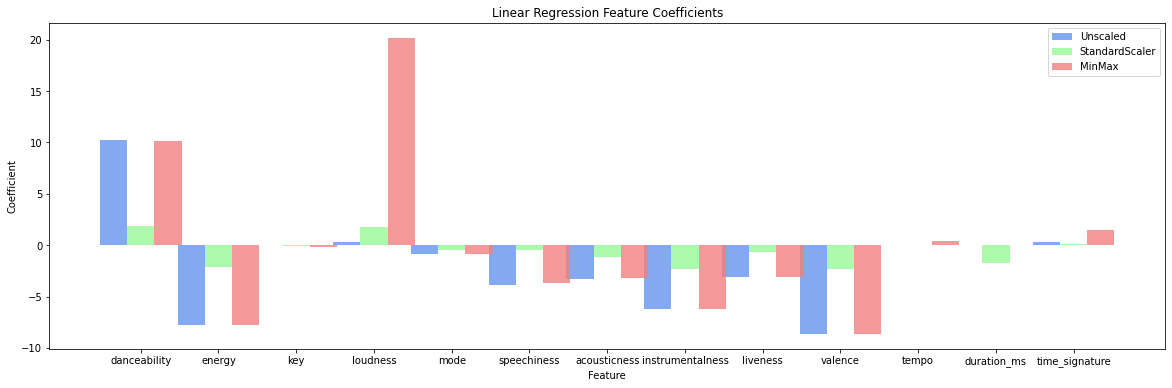

In [106]:
# Building the graph that will show the different coefficients for all the LR models. 
# https://pythonspot.com/matplotlib-bar-chart/

# Setting the MinMax coefficient to 0, so that the y-axis scale doesnt explode. 
update_lg_mm = best_model_mm.stages[-1].coefficients.copy()

update_lg_mm[-2] = 0

# data to plot
n_groups = 13

# create plot
fig, ax = plt.subplots(figsize=(20,6))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

lg_coef = plt.bar(index, best_model.stages[-1].coefficients, bar_width,
alpha=opacity,
color='cornflowerblue',
label='Unscaled')

lg_ss_coef = plt.bar(index + bar_width, best_model_ss.stages[-1].coefficients, bar_width,
alpha=opacity,
color='palegreen',
label='StandardScaler')

lg_mm_coef = plt.bar(index + bar_width + bar_width, update_lg_mm, bar_width,
alpha=opacity,
color='lightcoral',
label='MinMax')

plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Linear Regression Feature Coefficients')
plt.xticks(index + bar_width, ('danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature'))
plt.legend()

#plt.tight_layout()
plt.show()


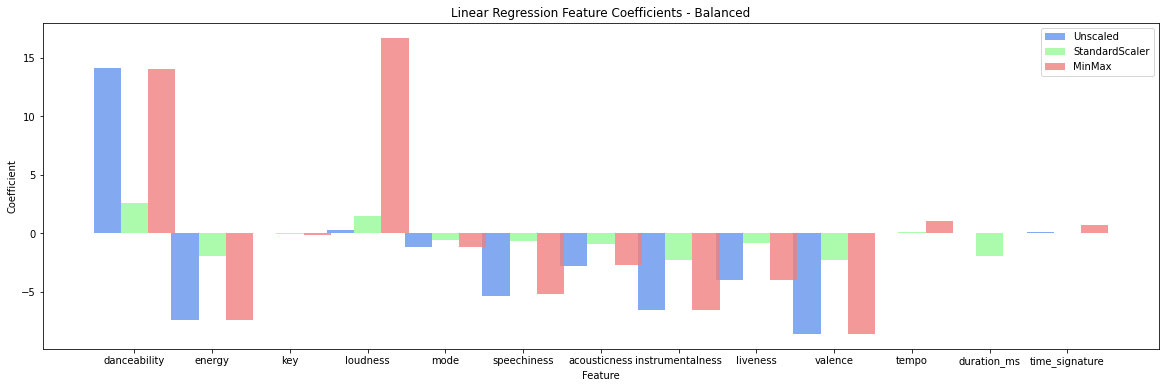

In [104]:
# Building the graph that will show the different coefficients for all the LR models using the balanced data set. 
# https://pythonspot.com/matplotlib-bar-chart/

# Setting the MinMax coefficient to 0, so that the y-axis scale doesnt explode. 
update_lg_bal = best_model_mm_bal.stages[-1].coefficients.copy()

update_lg_bal[-2] = 0

# data to plot
n_groups = 13

# create plot
fig, ax = plt.subplots(figsize=(20,6))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

lg_coef = plt.bar(index, best_model_balance.stages[-1].coefficients, bar_width,
alpha=opacity,
color='cornflowerblue',
label='Unscaled')

lg_ss_coef = plt.bar(index + bar_width, best_model_ss_bal.stages[-1].coefficients, bar_width,
alpha=opacity,
color='palegreen',
label='StandardScaler')

lg_mm_coef = plt.bar(index + bar_width + bar_width, update_lg_bal, bar_width,
alpha=opacity,
color='lightcoral',
label='MinMax')

plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Linear Regression Feature Coefficients - Balanced')
plt.xticks(index + bar_width, ('danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature'))
plt.legend()

#plt.tight_layout()
plt.show()


#### Logistic Regression

The following table contains the performance of the six models created using logistic regression. 

||||Logistic Regression||||
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
|||**Normal data set**|||**Balance data set**||
||**Unscaled Features**|**StandardScaler**|**MinMax scaler**|**Unscaled Features**|**StandardScaler**|**MinMax scaler**|
|**elasticNetParam**|0.000|0.000|0.000|0.000|0.000|0.000|
|**regParam**|0.010|0.010|0.010|0.010|0.010|0.010|
||||||||
|**AUC-ROC**|0.500|0.500|0.500|0.500|0.500|0.500|
|**Accuracy**|0.984|0.984|0.984|0.975|0.975|0.975|
|**Precision**|0.969|0.969|0.969|0.95|0.95|0.95|
|**Recall**|0.984|0.984|0.984|0.975|0.975|0.975|
||||||||
|**Model time (minutes)**|8.667|10.167|10.300|11.167|12.200|12.750|

The following table shows for each model, the intercept, and coefficients for each feature. 

||||Logistic Regression||||
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
|||**Normal data set**|||**Balance data set**||
||**Unscaled Features**|**StandardScaler**|**MinMax scaler**|**Unscaled Features**|**StandardScaler**|**MinMax scaler**|
||*Coefficient*|*Coefficient*|*Coefficient*|*Coefficient*|*Coefficient*|*Coefficient*|
|**danceability**|1.682|0.310|1.670|1.924|0.350|1.911|
|**energy**|-0.454|-0.123|-0.454|-0.608|-0.162|-0.608|
|**key**|-0.001|-0.002|-0.007|-0.001|-0.005|-0.015|
|**loudness**|0.034|0.193|2.181|0.037|0.210|2.355|
|**mode**|-0.101|-0.049|-0.101|-0.111|-0.053|-0.111|
|**speechiness**|0.111|0.014|0.107|0.088|0.011|0.085|
|**acousticness**|-0.177|-0.063|-0.176|-0.192|-0.067|-0.192|
|**instrumentalness**|-0.928|-0.339|-0.928|-1.072|-0.381|-1.072|
|**liveness**|-0.540|-0.109|-0.540|-0.574|-0.114|-0.574|
|**valence**|-0.252|-0.068|-0.252|-0.331|-0.087|-0.331|
|**tempo**|0.000|0.008|0.067|0.001|0.017|0.142|
|**duration_ms**|0.000|-0.227|-9.075|0|-0.264|-12.116|
|**time_signature**|0.038|0.018|0.189|0.016|0.007|0.080|
||||||||
|**Intercept**|-3.817|-3.817|-5.792|-3.151|-3.151|-5.326|

In general, the process of creating the models took a little longer, ranging from 8 minutes to 13 minutes. In all cases, the best models had the elasticNetParam set at 0 and the regParam at 0.01, which translates to a L2 regularization applied very weakly (0.01). Based on the accuracy, precision, and recall model evaluations, it was looking quite positive. The models could accurately predict the outcome in 98% percent of the cases. What was concerning was the fact that the AUC-ROC was at 0.5 for all six models. An AUC-ROC of 0 indicates a model that gets all outcome predictions wrong, whereas a 1 indicates a model that gets all outcome predictions correct [9]. Thus, the model was not a good one, since the predictions that it made was no better than random [10]. A user would be better off flipping a coin to predict whether a song would be popular or not. 

Even though the model was not predictive, it was interesting to note that danceability and loudness, had a positive coefficient in the scaled featured models. Indicating these two factors contribute to a positive outcome, which relates to a popular song. The features with a negative coefficient were instrumentalness and duration, which like the LR models, indicate that they were related to unpopular songs. 

These coefficients can be viewed in the following graphs. This was purely done to see what the coefficients looked like, since the models generated were not predictive. As before, the first graph illustrates the coefficients using the original data set and the second the coefficients using the balanced data set. Again, a reminder that the duration coefficient for the MinMax models were set to 0 in both graphs. 

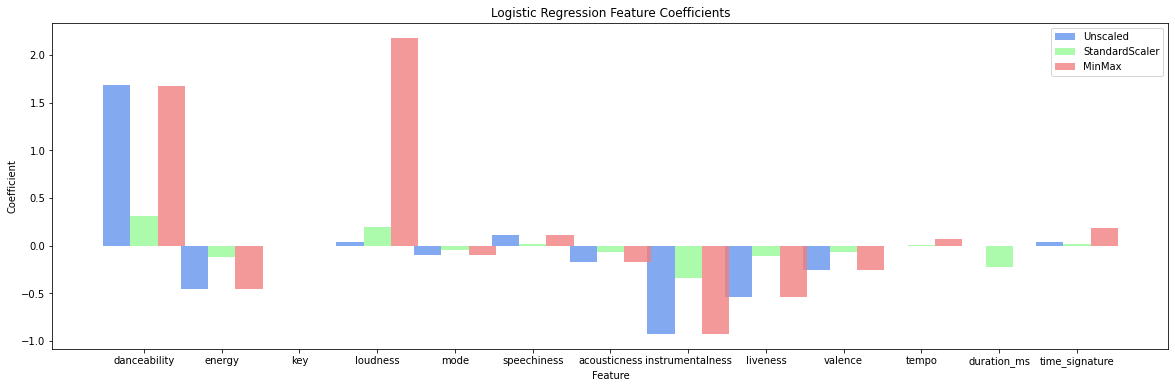

In [105]:
# Building the graph that will show the different coefficients for all the LGR models. 
# https://pythonspot.com/matplotlib-bar-chart/

# Setting the MinMax coefficient to 0, so that the y-axis scale doesnt explode. 
update_log_mm = best_model_log_mm.stages[-1].coefficients.copy()

update_log_mm[-2] = 0

# data to plot
n_groups = 13

# create plot
fig, ax = plt.subplots(figsize=(20,6))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

log_coef = plt.bar(index, best_model_log.stages[-1].coefficients, bar_width,
alpha=opacity,
color='cornflowerblue',
label='Unscaled')

log_ss_coef = plt.bar(index + bar_width, best_model_log_ss.stages[-1].coefficients, bar_width,
alpha=opacity,
color='palegreen',
label='StandardScaler')

log_mm_coef = plt.bar(index + bar_width + bar_width, update_log_mm, bar_width,
alpha=opacity,
color='lightcoral',
label='MinMax')

plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Logistic Regression Feature Coefficients')
plt.xticks(index + bar_width, ('danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature'))
plt.legend()

#plt.tight_layout()
plt.show()


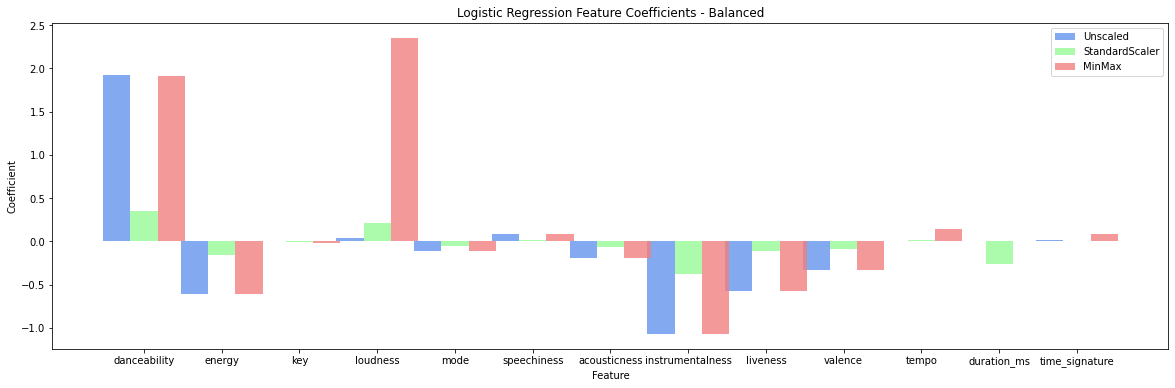

In [103]:
# Building the graph that will show the different coefficients for all the LGR models using the balanced data set. 
# https://pythonspot.com/matplotlib-bar-chart/

# Setting the MinMax coefficient to 0, so that the y-axis scale doesnt explode. 
update_log_mm_bal = best_model_log_mm_bal.stages[-1].coefficients.copy()

update_log_mm_bal[-2] = 0

# data to plot
n_groups = 13

# create plot
fig, ax = plt.subplots(figsize=(20,6))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

log_coef = plt.bar(index, best_model_log_bal.stages[-1].coefficients, bar_width,
alpha=opacity,
color='cornflowerblue',
label='Unscaled')

log_ss_coef = plt.bar(index + bar_width, best_model_log_ss_bal.stages[-1].coefficients, bar_width,
alpha=opacity,
color='palegreen',
label='StandardScaler')

log_mm_coef = plt.bar(index + bar_width + bar_width, update_log_mm_bal, bar_width,
alpha=opacity,
color='lightcoral',
label='MinMax')

plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.title('Logistic Regression Feature Coefficients - Balanced')
plt.xticks(index + bar_width, ('danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature'))
plt.legend()

#plt.tight_layout()
plt.show()


#### Random Forest Regressor

In the case of the RFR, the full data set was used with the unscaled features, meaning that only one model was created. This was because the Random Forest approach does not have any real assumptions since it is not influenced by outliers or unscaled data [11][12]. The following table contains the performance of the single model that was created using the Random Forest Regressor.  

||Random Forest Regressor|
|:---|:---:|
||**Normal data set**|
||**Unscaled Features**|
|**featureSubsetStrategy**|all|
|**maxDepth**|10|
|**numTrees**|100|
|**impurity**|variance|
|||
|**RMSE**|14.474|
|**R2**|0.169|
|**MAE**|11.699|
|||
|**Model time (hours)**|2.519|

The following table shows the feature importance of the generated model.

 ||Random Forest Regressor|
|:---|:---:|
||**Normal data set**|
||**Unscaled Features**|
||*Importance*|
|**danceability**|**0.157**|
|**energy**|0.042|
|**key**|0.002|
|**loudness**|**0.132**|
|**mode**|0.003|
|**speechiness**|0.035|
|**acousticness**|0.092|
|**instrumentalness**|**0.115**|
|**liveness**|0.031|
|**valence**|**0.111**|
|**tempo**|0.029|
|**duration_ms**|**0.250**|
|**time_signature**|0.002|

In the case of the RFR model creation, it took approximately 2.5 hours to cross validate the 36 different models. The final model used all the features, with a maxDepth of 10 and used 100 trees to get the best model. There was a slight improvement in both the RMSE and R^2. In the case of RMSE, the error was at around 14.5 on the prediction of popularity, which was an improvement of around 0.5 compared to the LR models.  In the case of R^2, the features explain almost twice the variation in popularity of the songs, which was quite positive. 

Based on the feature importance of the model, the same few features immerge: danceability, loudness, instrumentalness, valence, and duration. It was not clear what their relationship was to popularity, which was something that was made clear in the LR and LGR models through their positive or negative coefficients. 

The following graph highlights the feature importance for both the RFR and RFC models.

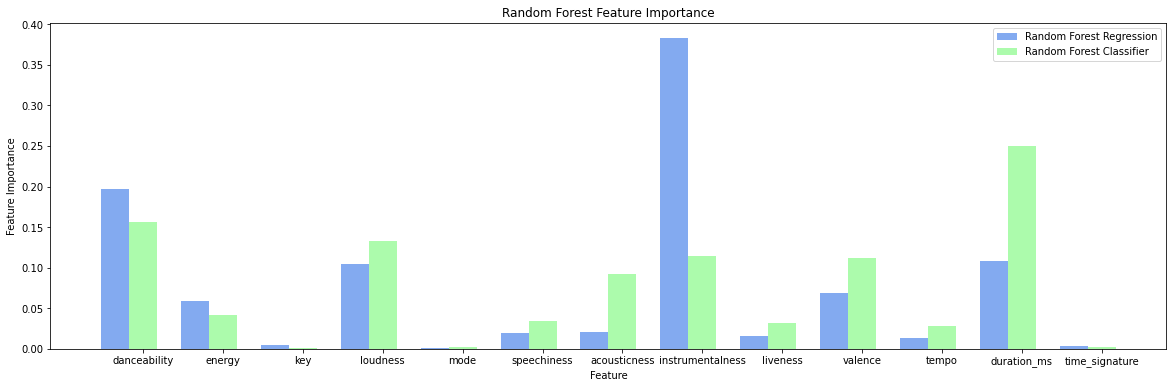

In [139]:
# Graphing the feature importance of the two different models - RFR and RFC.
# data to plot
n_groups = 13

# create plot
fig, ax = plt.subplots(figsize=(20,6))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rfc = plt.bar(index, best_model_rfc.stages[-1].featureImportances, bar_width,
alpha=opacity,
color='cornflowerblue',
label='Random Forest Regression')

rfr = plt.bar(index + bar_width, best_model_rfr.stages[-1].featureImportances, bar_width,
alpha=opacity,
color='palegreen',
label='Random Forest Classifier')

plt.xlabel('Feature')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.xticks(index + bar_width, ('danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature'))
plt.legend()

#plt.tight_layout()
plt.show()

#### Random Forest Classifier

The RFC share the same assumptions as the RFR, which means that the RFC analysis used the full data set with the unscaled features, meaning that only one model was created. The following table contains the performance of the single model that was created using the Random Forest Classifier.  

||Random Forest Classifier|
|:---|:---:|
||**Normal data set**|
||**Unscaled Features**|
|**featureSubsetStrategy**|all|
|**maxDepth**|10|
|**numTrees**|20|
|**impurity**|entropy|
|||
|**AUC-ROC**|0.500|
|**Accuracy**|0.984|
|**Precision**|0.984|
|**Recall**|0.984|
|||
|**Model time (minutes)**|4.241|

The following table shows the feature importance of the generated model.

||Random Forest Classifier|
|:---|:---:|
||**Normal data set**|
||**Unscaled Features**|
||*Importance*|
|**danceability**|**0.198**|
|**energy**|0.059|
|**key**|0.005|
|**loudness**|**0.104**|
|**mode**|0.001|
|**speechiness**|0.020|
|**acousticness**|0.021|
|**instrumentalness**|**0.383**|
|**liveness**|0.016|
|**valence**|0.069|
|**tempo**|0.014|
|**duration_ms**|**0.108**|
|**time_signature**|0.004|

In the case of the RFR model creation, it took approximately 4.2 hours to cross validate the 72 different models. The final model used all features, with a maxDepth of 10 and used 20 trees to generate the best model using entropy to base the impurity of a leaf node. As with the LGR, the accuracy, precision, and recall were promising, but the AUC-ROC was at 0.5, which indicates that the model was no better than a chance prediction. 

As with the LGR analysis, it was still interesting to look at the feature importance, even though the model was not predictive. The four features that had a feature performance of greater than 0.1 were: danceability, loudness, instrumentalness, and duration, which can be viewed in the graph above. 

#### Summary

The following graph highlights how often a feature was deemed important in explaining a song’s popularity. In the case of the LR and LGR models, a coefficient greater than 0.9 or less than -0.9 was used to indicate an important feature. For the RFR or RFC models, the feature importance was use, with a feature importance of greater than 0.1 used to count the feature as important. It is worth reiterating that both the LGR and RFC models were considered no better than chance, so they should be taken with a grain of salt. However, they do provide some insights into these features, which could be used in further research using this data set.  

Both danceability and instrumentalness emerged as important predictors in 12 of the 14 models generated. This was followed by loudness and duration (8 out of 14 models), with valence coming in third (one in every second model). 

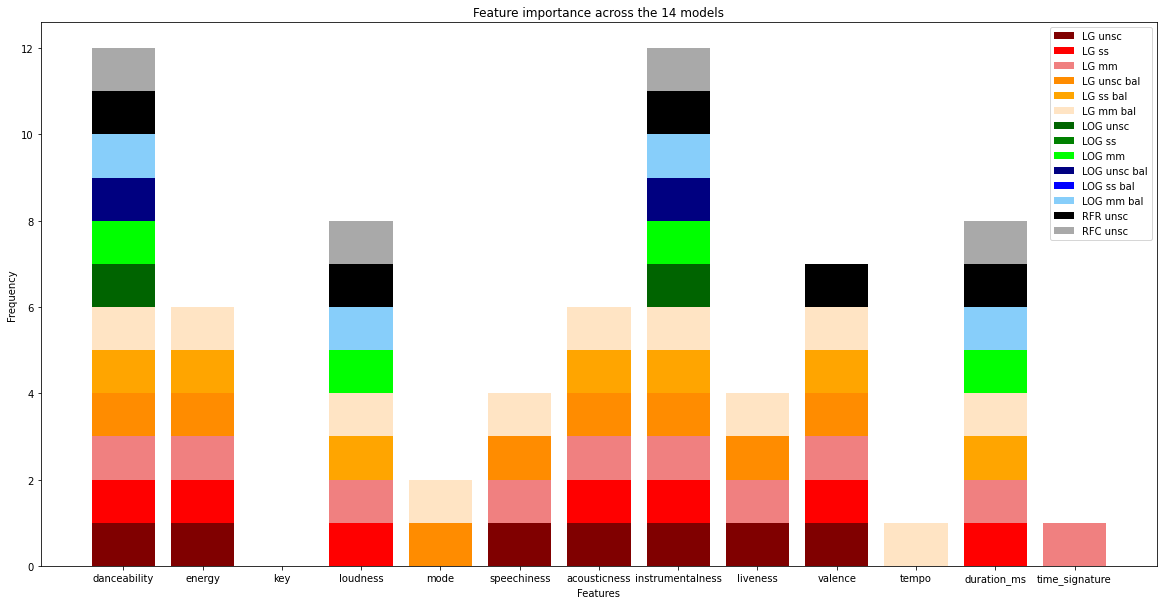

In [11]:
# Creating a graph that illustrates how often a feature is important across all the features. 

#Inspiration:
# https://www.geeksforgeeks.org/create-a-stacked-bar-plot-in-matplotlib/

# Total graphs indicating which factors have a strong coefficient or importance. 

y1 =  np.array([1,1,0,0,0,1,1,1,1,1,0,0,0])
y2 =  np.array([1,1,0,1,0,0,1,1,0,1,0,1,0])
y3 =  np.array([1,1,0,1,0,1,1,1,1,1,0,1,1])
y4 =  np.array([1,1,0,0,1,1,1,1,1,1,0,0,0])
y5 =  np.array([1,1,0,1,0,0,1,1,0,1,0,1,0])
y6 =  np.array([1,1,0,1,1,1,1,1,1,1,1,1,0])
y7 =  np.array([1,0,0,0,0,0,0,1,0,0,0,0,0])
y8 =  np.array([0,0,0,0,0,0,0,0,0,0,0,0,0])
y9 =  np.array([1,0,0,1,0,0,0,1,0,0,0,1,0])
y10 = np.array([1,0,0,0,0,0,0,1,0,0,0,0,0])
y11 = np.array([0,0,0,0,0,0,0,0,0,0,0,0,0])
y12 = np.array([1,0,0,1,0,0,0,1,0,0,0,1,0])
y13 = np.array([1,0,0,1,0,0,0,1,0,1,0,1,0])
y14 = np.array([1,0,0,1,0,0,0,1,0,0,0,1,0])

x = ['danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_ms','time_signature']

plt.figure(figsize = (20,10))

# plot bars in stack manner
plt.bar(x, y1, color='maroon')
plt.bar(x, y2, bottom=y1, color='red')
plt.bar(x, y3, bottom= y1 + y2, color='lightcoral')
plt.bar(x, y4, bottom=y1+y2+y3, color='darkorange')
plt.bar(x, y5, bottom=y1+y2+y3+y4, color='orange')
plt.bar(x, y6, bottom=y1+y2+y3+y4+y5, color='bisque')
plt.bar(x, y7, bottom=y1+y2+y3+y4+y5+y6, color='darkgreen')
plt.bar(x, y8, bottom=y1+y2+y3+y4+y5+y6+y7, color='green')
plt.bar(x, y9, bottom=y1+y2+y3+y4+y5+y6+y7+y8, color='lime')
plt.bar(x, y10, bottom=y1+y2+y3+y4+y5+y6+y7+y8+y9, color='navy')
plt.bar(x, y11, bottom=y1+y2+y3+y4+y5+y6+y7+y8+y9+y10, color='blue')
plt.bar(x, y12, bottom=y1+y2+y3+y4+y5+y6+y7+y8+y9+y10+y11, color='lightskyblue')
plt.bar(x, y13, bottom=y1+y2+y3+y4+y5+y6+y7+y8+y9+y10+y11+y12, color='black')
plt.bar(x, y14, bottom=y1+y2+y3+y4+y5+y6+y7+y8+y9+y10+y11+y12+y13, color='darkgrey')

plt.xlabel("Features")
plt.ylabel("Frequency")
plt.legend(["LG unsc", "LG ss", "LG mm", "LG unsc bal", "LG ss bal", "LG mm bal", "LOG unsc", "LOG ss", "LOG mm", "LOG unsc bal", "LOG ss bal", "LOG mm bal", "RFR unsc", "RFC unsc"])
plt.title("Feature importance across the 14 models")
plt.show()


## Conclusion 

As stated in the introduction, the goal of the project was to investigate whether a model could be built to predict a song’s popularity based on one or more of the thirteen different features a song has. Different machine learning techniques were used to try to achieve the goal of creating an accurate predictive model, specifically linear regression (LR), logistic regression (LGR), random forest regression (RFR), and random forest classifier (RFC). Depending on which approach was used, the models would have a slightly different prediction outcome. In the case of LR or RFR, the predication would range between 0 (unpopular) to 100 (popular), which would be in the same scale as the original outcome feature. For LGR or RFC, the outcome had to be translated into a dichotomous prediction: 0 (unpopular) or 1 (popular). This was done by converting the popularity feature into a dichotomous feature, whereby unpopular songs were defined as having a popularity of less than or equal to 59 versus popular songs having a score of 60 or above. 

In the preliminary investigation into the different features, it became clear that the data was skewed. This was especially the case with the popularity feature, where a lot of songs had a very low popularity score. For instance, around 158,000 songs of the million songs had a popularity of 0. Therefore, it was decided to run the different machine learning models on both the original data set and a more balances data set around the popularity feature. The investigation also highlighted that a few features had a different scale than the rest of the features, which meant that the features needed to be scaled due to the assumptions of two of the machine learning techniques: LR and LGR. Therefore, the analysis for the specific machine learning approaches was conducted using different scaling approaches. 

Based on the results, it was safe to say that even though the accuracy, precision and recall of the LGR and RFC were quite good, the AUC-ROC indicated that the models were no better than a chance prediction. Therefore, they could be ignored as a possible contender for useful predictor models for song popularity. In the case of the LR model, the better models emerged using the more balanced data set, with a slightly lower RMSE value and a higher R^2 value. The best performing model was the RFR, with a slightly lower RMSE and an R^2 that was almost double compared to the LR model. 

Based on these two models specifically, the important feature that emerged were duration, instrumentalness, danceability, loudness, and valence. Even though the classification models (LGR & RFC) did not perform better than chance, they also supported these features as important in predicting the popularity of the songs. 

The coefficients of these important features provide some insights into what makes a popular song. It should be said that each coefficient should be taken in isolation, since they indicate how each feature contributes to the outcome as they increase. Thus, illustrating what happens when a song increases in a specific feature. In the case of danceability and loudness, there was a positive relationship with popularity, whereas the other features had a negative relationship. To create a picture of what this means, songs considered danceable and were loud were likely to lead to being considered a popular song. Songs that were too positive (valence), had vocals in them (instrumentalness), and were too long, would likely lead to an unpopular song. 


## Discussion

Even though the LR or RFR were illustrated as descent models, there is room for improvement. The R^2 for the LR model was close to being considered a medium effect size, whereas the RFR was soundly there. However, the RMSE indicates that the mean error in prediction was around 14 points in popularity, which is not ideal for a predictive model. On a 100 point scale, that is a 14% error margin. A possible improvement could be found in the cross-validation pipeline, since the evaluator used was based on RMSE, which is a L2 loss measure. This could have affected which parameters emerged as the best in generating the best model. Therefore, for the next time, the cross-validation could also be conducted using a MAE evaluator, which is a L1 loss measure. This might have affected the type of parameters that emerged in creating the best model. Another recommendation would be to potentially investigate other machine learning algorithms to see whether popularity could be predicted using the 13 numerical features. The regression or classifier models might not have been the best approach for the data set. For example, a simple machine learning algorithm could be used like KNN, whereby a song is compared to other songs that are close to it in characteristics and thus get the common label (popularity) of those similar songs. 

Something that caught the eye was the extreme coefficients found in some of the scaled models, specifically the MinMax scaling. Duration goes from having no effect in the unscaled model (0.0), to a slight negative effect in the StandardScaled model (-1.958), to a very large effect in the MinMax model (-89.905). The popularity scale ranges from 0 to 100, which means that duration in the MinMax model penalizes a song quite heavily the longer it was, subtracting almost 90 points in popularity for the longest songs. This could be accurate, but further research should be conducted into investigating whether that was the case. Two approaches are outlined. 

The first approach would be to focus on the most important features and remove the rest from the model building. For example, key, mode, tempo, and time signature could be removed from the model creation, since they are rarely seen as contributing in predicting the outcome. It would be interesting to see how the models would look like with only danceability, instrumentalness, loudness, duration, and valence. What would the coefficients look like? Would duration be as extreme? 

The second approach would be to try and balance all the features. Based on the distribution graphs, the only three features that look like they have a decent spread of values are danceability, mode, and valence. The rest of the features are heavily skewed. Therefore, it would be interesting to investigate whether a more balance data set on all features might produce a more accurate model. It might also be worth looking at initially balancing by genre of the song and looking at the distributions of the features. Looking at the genre distribution, there is a lot of black metal, gospel, and ambient songs. This might impact how frequent certain characteristic are on each. 

This links nicely to the next recommendation, which would be to include genre as a feature in the model building. Seeing that the most frequent genres are black metal, gospel, and ambient music, these are not what would be considered mainstream music genres. This could be why there are a lot of unpopular songs in the data set. The genre feature would need to be turned into a categorical variable using the StringIndex method and plugged into the model. It could be the deciding factor that indicates whether a song is considered popular, in combination with some of the other features highlighted above. Again, it would be important to make sure to do a correlation analysis before running the models, since some genres might be heavily correlated with other features (house + danceability). 

Lastly, it should be noted that the seed was not set for the cross-validation process. This should have been done to ensure that the results could be replicated. However, the models were saved so that if anyone wanted to use the models for further analysis, they could do that. 

## References

[1] (2023, September 16th). *PySpark Overview*. Spark.  https://spark.apache.org/docs/latest/api/python/index.html#:~:text=PySpark%20is%20the%20Python%20API,for%20interactively%20analyzing%20your%20data.

[2] Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media, Inc.

[3] Kang, C. (2023, September 16th). *Ensembles and Pipelines in PySpark*. Goodboychan. https://goodboychan.github.io/python/datacamp/pyspark/machine_learning/2020/08/11/02-Ensembles-and-Pipelines-in-PySpark.html#Optimizing-flights-linear-regression 

[4] Jagdeesh. (2023, September 16th). *PySpark Logistic Regression – How to Build and Evaluate Logistic Regression Models using PySpark Mllib*. Machine Learning +. 
 https://www.machinelearningplus.com/pyspark/pyspark-logistic-regression/ 

[5] Immadisetty, S. (2023, September 16th). *Methods of the LinearRegression class in PySpark*. Medium. https://towardsdev.com/pyspark-linearregression-hyper-parameters-fb3f92e8897b 

[6] Allwright, S. (2023, September 16th). *How to interpret RMSE*. Stephen Allwright. https://stephenallwright.com/interpret-rmse/ 

[7] Allwright, S. (2023, September 16th). *How to interpret R squared*. Stephen Allwright. https://stephenallwright.com/interpret-r-squared/ 

[8] Cohen J. (1988). Statistical Power Analysis for the Behavioral Sciences, 2nd Ed. Hillsdale, NJ: Laurence Erlbaum Associates

[9] (2023, September 16th). *Classification: ROC Curve and AUC*. Machine Learning.  https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc#:~:text=AUC%20stands%20for%20%22Area%20under,across%20all%20possible%20classification%20thresholds. 

[10] (2023, September 16th). *Classification: Check Your Understanding (ROC and AUC)*. Machine Learning. https://developers.google.com/machine-learning/crash-course/classification/check-your-understanding-roc-and-auc#:~:text=This%20ROC%20curve%20has%20an%20AUC%20of%200.5%2C%20meaning%20it,no%20better%20than%20random%20guessing. 

[11] Vishalmendekarhere. (2023, September 16th). *It’s all about Assumptions, Pros & Cons*. Medium. https://medium.com/swlh/its-all-about-assumptions-pros-cons-497783cfed2d 

[12] Arya, N. (2023, September 16th). *Does the Random Forest Algorithm Need Normalization?*. KDnuggets. https://www.kdnuggets.com/2022/07/random-forest-algorithm-need-normalization.html 